In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
df1=pd.read_csv(r"table_219.csv.xls")
df2=pd.read_csv(r"table_220.csv.xls")
df3=pd.read_csv(r"table_221.csv.xls")

In [4]:
df=pd.concat([df1,df2,df3],axis=0,ignore_index=True)

In [5]:
df.columns

Index(['studyName', 'Sample Number', 'Species', 'Region', 'Island', 'Stage',
       'Individual ID', 'Clutch Completion', 'Date Egg', 'Culmen Length (mm)',
       'Culmen Depth (mm)', 'Flipper Length (mm)', 'Body Mass (g)', 'Sex',
       'Delta 15 N (o/oo)', 'Delta 13 C (o/oo)', 'Comments'],
      dtype='object')

In [6]:
df.head()
drop_col=['studyName', 'Sample Number','Region','Stage',  'Date Egg', 'Delta 15 N (o/oo)', 'Delta 13 C (o/oo)', 'Comments']
df.drop(columns=drop_col,inplace=True)

In [7]:
df.columns

Index(['Species', 'Island', 'Individual ID', 'Clutch Completion',
       'Culmen Length (mm)', 'Culmen Depth (mm)', 'Flipper Length (mm)',
       'Body Mass (g)', 'Sex'],
      dtype='object')

# DQ

In [8]:
df.head()

,Species,Island,Individual ID,Clutch Completion,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex
0,Adelie Penguin (Pygoscelis adeliae),Torgersen,N1A1,Yes,39.1,18.7,181.0,3750.0,MALE
1,Adelie Penguin (Pygoscelis adeliae),Torgersen,N1A2,Yes,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie Penguin (Pygoscelis adeliae),Torgersen,N2A1,Yes,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie Penguin (Pygoscelis adeliae),Torgersen,N2A2,Yes,NaN,NaN,NaN,NaN,NaN
4,Adelie Penguin (Pygoscelis adeliae),Torgersen,N3A1,Yes,36.7,19.3,193.0,3450.0,FEMALE


# Du

In [9]:
df[df.duplicated()]

,Species,Island,Individual ID,Clutch Completion,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex


accuracy,uniqueness,missing,consistency,time,valid

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Species              344 non-null    object 
 1   Island               344 non-null    object 
 2   Individual ID        344 non-null    object 
 3   Clutch Completion    344 non-null    object 
 4   Culmen Length (mm)   342 non-null    float64
 5   Culmen Depth (mm)    342 non-null    float64
 6   Flipper Length (mm)  342 non-null    float64
 7   Body Mass (g)        342 non-null    float64
 8   Sex                  334 non-null    object 
dtypes: float64(4), object(5)
memory usage: 24.3+ KB


In [11]:
df.describe()

,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g)
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [12]:
df.shape

(344, 9)

In [13]:
for col in df.select_dtypes("object"):
    print(df[col].value_counts())


Species
Adelie Penguin (Pygoscelis adeliae)          152
Gentoo penguin (Pygoscelis papua)            124
Chinstrap penguin (Pygoscelis antarctica)     68
Name: count, dtype: int64
Island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64
Individual ID
N61A2     3
N29A2     3
N22A1     3
N22A2     3
N23A1     3
         ..
N84A2     1
N84A1     1
N83A2     1
N83A1     1
N100A2    1
Name: count, Length: 190, dtype: int64
Clutch Completion
Yes    308
No      36
Name: count, dtype: int64
Sex
MALE      168
FEMALE    165
.           1
Name: count, dtype: int64


In [14]:
df.columns

Index(['Species', 'Island', 'Individual ID', 'Clutch Completion',
       'Culmen Length (mm)', 'Culmen Depth (mm)', 'Flipper Length (mm)',
       'Body Mass (g)', 'Sex'],
      dtype='object')

In [15]:
df['Species']=df['Species'].apply(lambda x:x.split()[0])

In [16]:
df[df['Sex']=="."]

,Species,Island,Individual ID,Clutch Completion,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex
268,Gentoo,Biscoe,N36A1,Yes,44.5,15.7,217.0,4875.0,.


In [17]:
df[df['Individual ID']=="N36A1"]

,Species,Island,Individual ID,Clutch Completion,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex
74,Adelie,Torgersen,N36A1,Yes,35.5,17.5,190.0,3700.0,FEMALE
162,Gentoo,Biscoe,N36A1,No,40.9,13.7,214.0,4650.0,FEMALE
268,Gentoo,Biscoe,N36A1,Yes,44.5,15.7,217.0,4875.0,.


In [18]:
df.iloc[268,-1]="FEMALE"

In [19]:
df[df['Sex'].isnull()]

,Species,Island,Individual ID,Clutch Completion,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex
3,Adelie,Torgersen,N2A2,Yes,NaN,NaN,NaN,NaN,NaN
8,Adelie,Torgersen,N5A1,Yes,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,N5A2,Yes,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,N6A1,Yes,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,N6A2,Yes,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,N29A2,Yes,37.5,18.9,179.0,2975.0,NaN
178,Gentoo,Biscoe,N46A1,Yes,44.5,14.3,216.0,4100.0,NaN
218,Gentoo,Biscoe,N51A1,Yes,46.2,14.4,214.0,4650.0,NaN
256,Gentoo,Biscoe,N24A1,Yes,47.3,13.8,216.0,4725.0,NaN
271,Gentoo,Biscoe,N38A2,No,NaN,NaN,NaN,NaN,NaN


In [20]:
df.columns

Index(['Species', 'Island', 'Individual ID', 'Clutch Completion',
       'Culmen Length (mm)', 'Culmen Depth (mm)', 'Flipper Length (mm)',
       'Body Mass (g)', 'Sex'],
      dtype='object')

In [21]:
df.dropna(subset=['Culmen Length (mm)', 'Culmen Depth (mm)', 'Flipper Length (mm)',
       'Body Mass (g)'],inplace=True)

In [22]:
df.shape

(342, 9)

In [23]:
df.drop(columns=['Individual ID'],inplace=True)

In [24]:
df

,Species,Island,Clutch Completion,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex
0,Adelie,Torgersen,Yes,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,Yes,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,Yes,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,Yes,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,Yes,39.3,20.6,190.0,3650.0,MALE
...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,Yes,55.8,19.8,207.0,4000.0,MALE
340,Chinstrap,Dream,No,43.5,18.1,202.0,3400.0,FEMALE
341,Chinstrap,Dream,No,49.6,18.2,193.0,3775.0,MALE
342,Chinstrap,Dream,Yes,50.8,19.0,210.0,4100.0,MALE


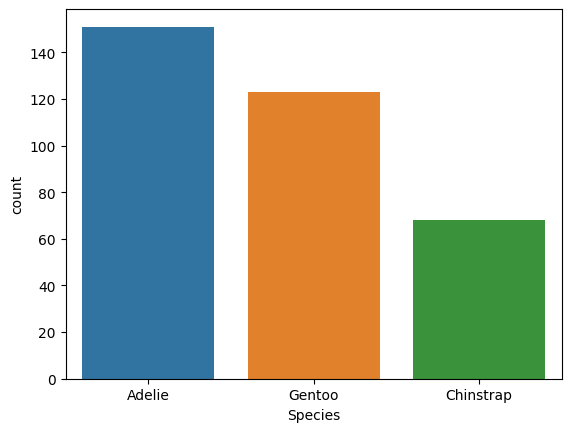

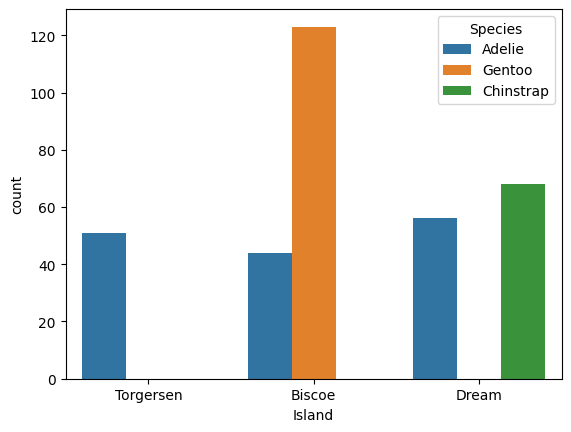

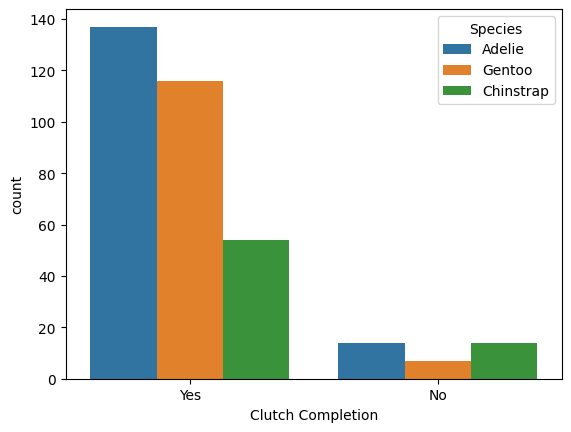

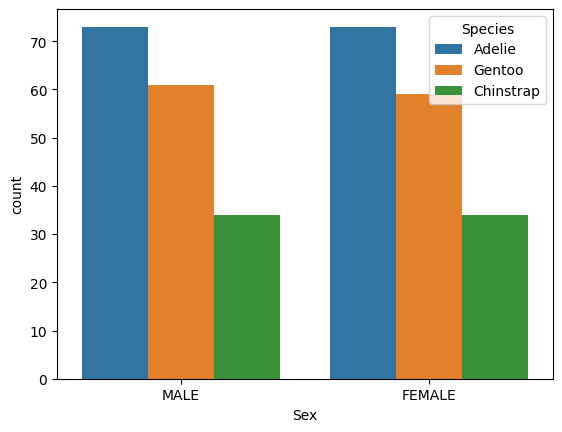

In [25]:
for col in df.select_dtypes("object"):
    sns.countplot(data=df,x=col,hue="Species")
    plt.show()

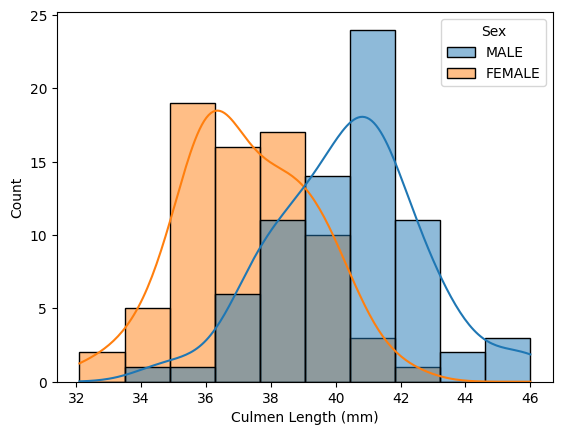

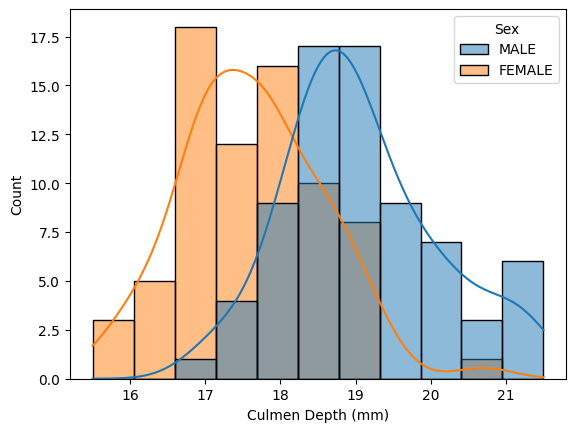

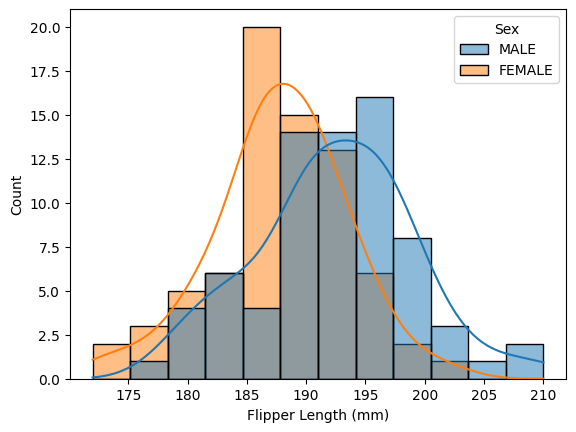

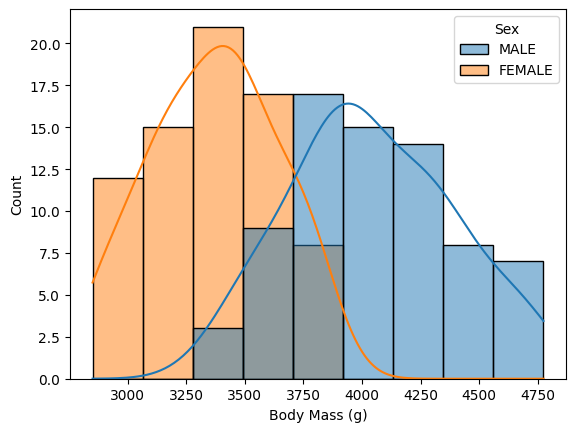

In [26]:
df1=df[df["Species"]=="Adelie"]

for col in df.select_dtypes("number"):
    sns.histplot(data=df1,x=col,kde=True,hue="Sex")
    plt.show()

In [27]:
df.columns

Index(['Species', 'Island', 'Clutch Completion', 'Culmen Length (mm)',
       'Culmen Depth (mm)', 'Flipper Length (mm)', 'Body Mass (g)', 'Sex'],
      dtype='object')

<Axes: xlabel='Culmen Length (mm)', ylabel='Culmen Depth (mm)'>

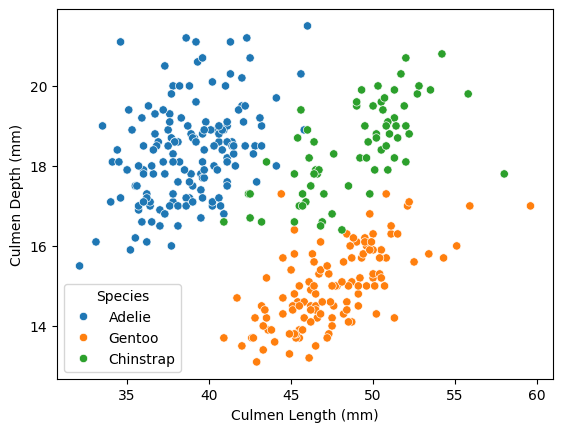

In [28]:
sns.scatterplot(df,x="Culmen Length (mm)",y="Culmen Depth (mm)",hue="Species")


<Axes: xlabel='Culmen Length (mm)', ylabel='Culmen Depth (mm)'>

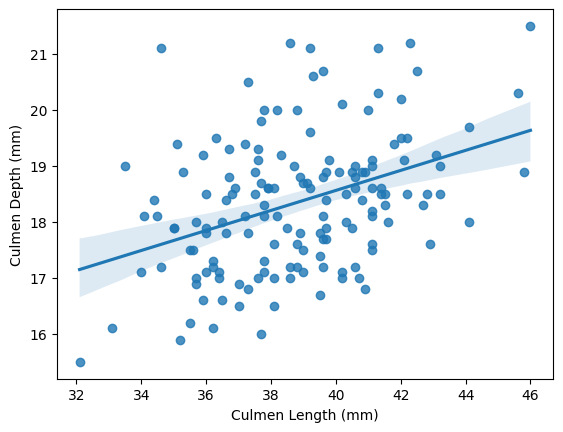

In [29]:
sns.regplot(df1,x="Culmen Length (mm)",y="Culmen Depth (mm)")

In [30]:
df2=df[df["Species"]=="Gentoo"]

In [31]:
df2.select_dtypes("number").corr()

,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g)
Culmen Length (mm),1.000000,0.643384,0.661162,0.669166
Culmen Depth (mm),0.643384,1.000000,0.706563,0.719085
Flipper Length (mm),0.661162,0.706563,1.000000,0.702667
Body Mass (g),0.669166,0.719085,0.702667,1.000000


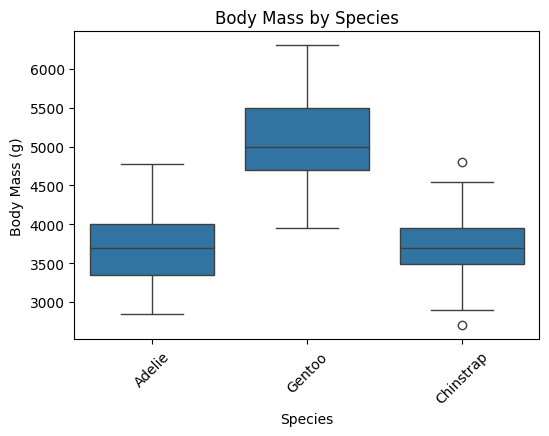

In [32]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Species", y="Body Mass (g)")
plt.title("Body Mass by Species")
plt.xticks(rotation=45)
plt.show()

In [33]:
fig = px.scatter(df,
                 x="Flipper Length (mm)",
                 y="Body Mass (g)",
                 title="Flipper Length vs Body Mass")
fig.show()

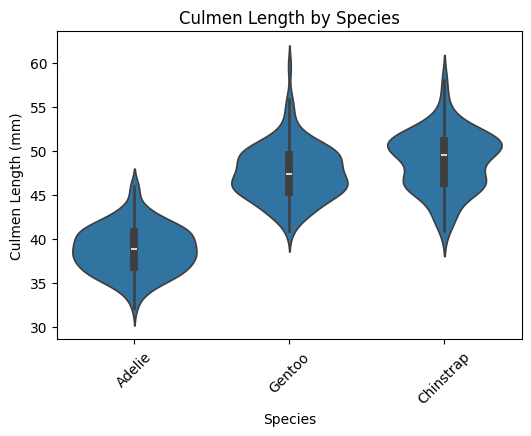

In [34]:
plt.figure(figsize=(6,4))
sns.violinplot(data=df, x="Species", y="Culmen Length (mm)")
plt.title("Culmen Length by Species")
plt.xticks(rotation=45)
plt.show()


In [35]:
fig = px.histogram(df,
                   x="Island",
                   color="Species",
                   barmode="group",
                   title="Species by Island")
fig.show()


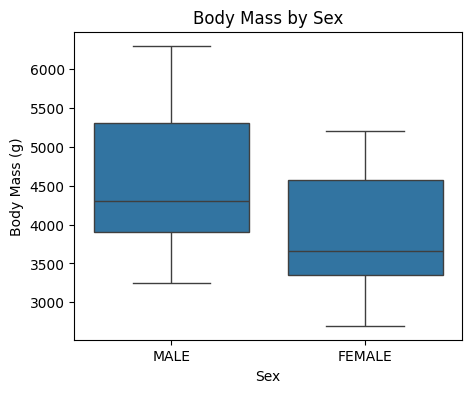

In [36]:
plt.figure(figsize=(5,4))
sns.boxplot(data=df, x="Sex", y="Body Mass (g)")
plt.title("Body Mass by Sex")
plt.show()


In [37]:
fig = px.scatter(df,
                 x="Flipper Length (mm)",
                 y="Body Mass (g)",
                 color="Species",
                 title="Flipper vs Body Mass by Species")
fig.show()


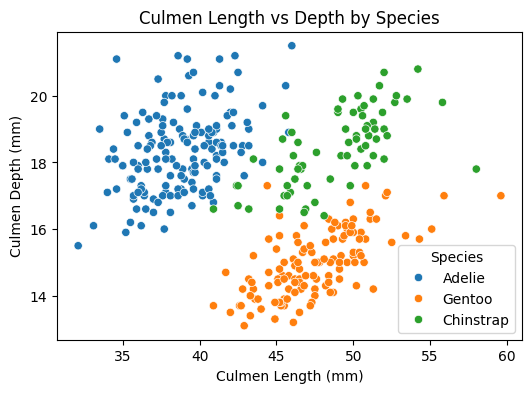

In [38]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df,
                x="Culmen Length (mm)",
                y="Culmen Depth (mm)",
                hue="Species")
plt.title("Culmen Length vs Depth by Species")
plt.show()


In [39]:
fig = px.box(df,
             x="Island",
             y="Body Mass (g)",
             color="Species",
             title="Body Mass by Island and Species")
fig.show()


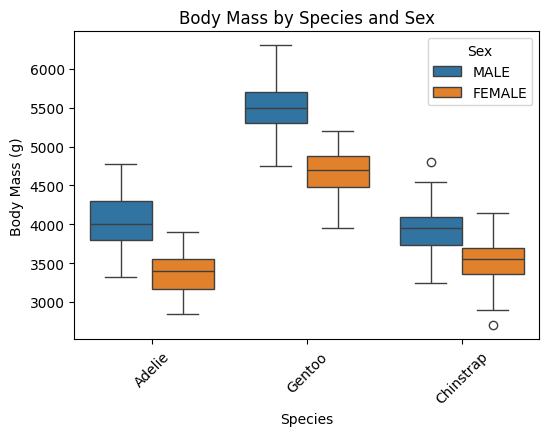

In [40]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Species", y="Body Mass (g)", hue="Sex")
plt.title("Body Mass by Species and Sex")
plt.xticks(rotation=45)
plt.show()


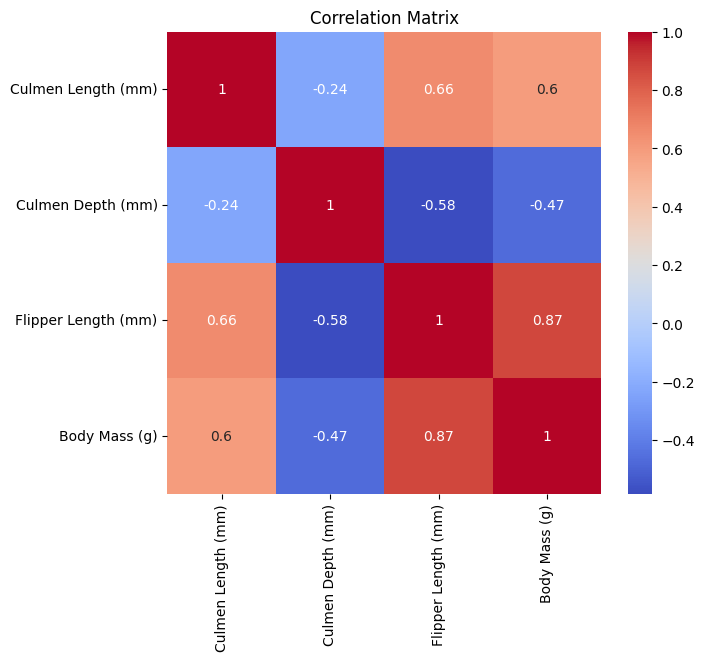

In [42]:
plt.figure(figsize=(7,6))
sns.heatmap(df.select_dtypes(include=['float64', 'int64']).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


In [43]:
fig = px.scatter_matrix(df,
                        dimensions=['Culmen Length (mm)',
                                    'Culmen Depth (mm)',
                                    'Flipper Length (mm)',
                                    'Body Mass (g)'],
                        color="Species",
                        title="Scatter Matrix by Species")
fig.show()
